In [ ]:
import json
import re
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# Chargement du dataset JSON dans un DataFrame
DATA_PATH = Path("../../financial_dataset/finance_dataset_final.json")
with open(DATA_PATH, encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)

len(df), list(df.columns)

(2997, ['instruction', 'input', 'output'])

In [29]:
# Verification du schema chaque exemple doit avoir instruction/input/output
REQUIRED = {"instruction", "input", "output"}
schema_ok = all(REQUIRED.issubset(r.keys()) for r in data)
extra_keys = set().union(*[set(r.keys()) for r in data]) - REQUIRED

schema_ok, extra_keys

(True, set())

In [30]:
# Controle du type Python de chaque colonne (on attend des chaines)
type_report = {c: df[c].map(type).value_counts().to_dict() for c in df.columns}

type_report

{'instruction': {str: 2997}, 'input': {str: 2997}, 'output': {str: 2997}}

In [31]:
# Detection des champs vides ou ne contenant que des espaces
def is_blank(x):
    return x is None or (isinstance(x, str) and x.strip() == "")
empty_counts = {c: int(df[c].map(is_blank).sum()) for c in df.columns}

empty_counts

{'instruction': 0, 'input': 2997, 'output': 0}

In [32]:
# Comptage des doublons (lignes entieres, instructions, paires instruction+output)
dup_full = int(df.duplicated().sum())
dup_instruction = int(df["instruction"].duplicated().sum())
dup_io = int(df.duplicated(subset=["instruction", "output"]).sum())

dup_full, dup_instruction, dup_io

(482, 482, 482)

In [33]:
# Statistiques de longueur en caracteres et en mots pour chaque champ
for c in ["instruction", "input", "output"]:
    df[f"{c}_chars"] = df[c].fillna("").str.len()
    df[f"{c}_words"] = df[c].fillna("").str.split().map(len)
    
df[[f"{c}_chars" for c in REQUIRED] + [f"{c}_words" for c in REQUIRED]].describe()

,instruction_chars,output_chars,input_chars,instruction_words,output_words,input_words
count,2997.000000,2997.000000,2997.0,2997.000000,2997.000000,2997.0
mean,207.104438,1337.163497,0.0,31.663330,206.435102,0.0
std,172.017758,688.225435,0.0,26.304823,105.445524,0.0
min,20.000000,24.000000,0.0,3.000000,1.000000,0.0
25%,75.000000,1040.000000,0.0,12.000000,169.000000,0.0
50%,169.000000,1521.000000,0.0,25.000000,238.000000,0.0
75%,286.000000,1813.000000,0.0,42.000000,277.000000,0.0
max,1931.000000,4041.000000,0.0,285.000000,609.000000,0.0


In [36]:
# Longueur totale par exemple et estimation du nombre de tokens (~4 caracteres/token)
df["total_chars"] = df["instruction_chars"] + df["input_chars"] + df["output_chars"]
df["approx_tokens"] = (df["total_chars"] / 4).round().astype(int)

df[["total_chars", "approx_tokens"]].describe()

,total_chars,approx_tokens
count,2997.000000,2997.000000
mean,1544.267935,386.070404
std,781.731950,195.438892
min,64.000000,16.000000
25%,1213.000000,303.000000
50%,1723.000000,431.000000
75%,2054.000000,514.000000
max,4576.000000,1144.000000


In [38]:
# Risque de troncature (exemples depassant la longueur de contexte visee)
MAX_SEQ_LEN = 2048
over_limit = df[df["approx_tokens"] > MAX_SEQ_LEN]

len(over_limit), df["approx_tokens"].quantile([0.5, 0.9, 0.95, 0.99]).to_dict()

(0, {0.5: 431.0, 0.9: 590.0, 0.95: 645.1999999999998, 0.99: 758.3199999999997})

In [39]:
# Detection de caracteres de controle et part d'exemples contenant du non-ASCII
def has_control_chars(x):
    return bool(re.search(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", x or ""))
control_rows = df[df["instruction"].map(has_control_chars) | df["output"].map(has_control_chars)]
non_ascii_share = df["output"].fillna("").map(lambda s: any(ord(c) > 127 for c in s)).mean()

len(control_rows), round(float(non_ascii_share), 4)

(0, 0.2019)

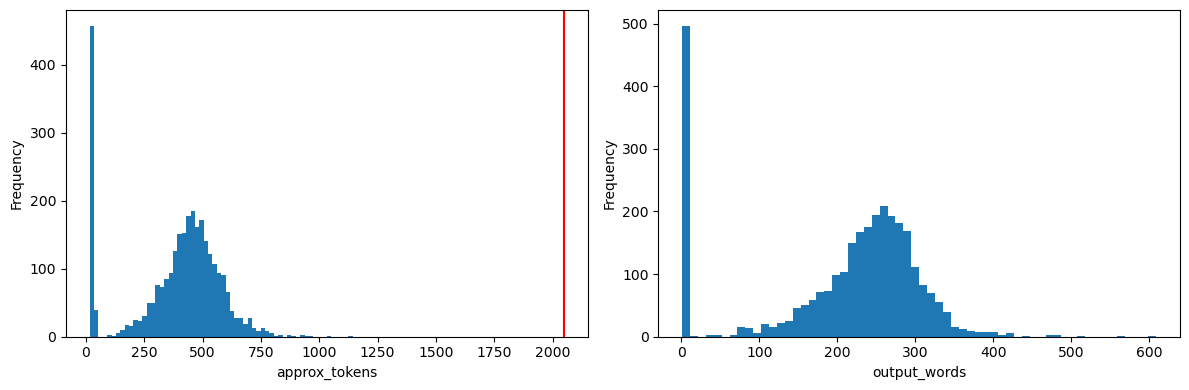

In [40]:
# Visualisation des distributions de longueur (tokens estimes et mots d'output)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["approx_tokens"].plot.hist(bins=60, ax=ax[0])
ax[0].axvline(MAX_SEQ_LEN, color="red")
ax[0].set_xlabel("approx_tokens")
df["output_words"].plot.hist(bins=60, ax=ax[1])
ax[1].set_xlabel("output_words")
plt.tight_layout()
plt.show()

In [41]:
# Rapport de synthese
report = {
    "n_records": len(df),
    "schema_ok": schema_ok,
    "extra_keys": sorted(extra_keys),
    "empty_instruction": empty_counts["instruction"],
    "empty_output": empty_counts["output"],
    "duplicate_rows": dup_full,
    "duplicate_instructions": dup_instruction,
    "control_char_rows": int(len(control_rows)),
    "over_token_limit": int(len(over_limit)),
    "median_approx_tokens": int(df["approx_tokens"].median()),
    "max_approx_tokens": int(df["approx_tokens"].max()),
}

report

{'n_records': 2997,
 'schema_ok': True,
 'extra_keys': [],
 'empty_instruction': 0,
 'empty_output': 0,
 'duplicate_rows': 482,
 'duplicate_instructions': 482,
 'control_char_rows': 0,
 'over_token_limit': 0,
 'median_approx_tokens': 431,
 'max_approx_tokens': 1144}

## Interpretation des resultats

Le dataset compte **2997 exemples** au format instruction/input/output attendu pour le fine-tuning, avec un schema parfaitement coherent : aucune cle parasite, aucun champ `instruction` ou `output` vide, aucun caractere de controle et des types homogenes (chaines de caracteres). Les longueurs sont egalement saines : la mediane tourne autour de quelques centaines de tokens estimes et le maximum reste largement sous la limite de contexte de 2048 tokens, ce qui ecarte tout risque de troncature (l'estimation se base sur un ratio approximatif de 4 caracteres par token, suffisant a ce stade de validation des donnees). Le seul point d'attention concerne les **482 doublons complets** (instructions identiques), ces redondances peuvent biaiser l'entrainement en sur-ponderant certains exemples et meritent une deduplication avant le fine-tuning. En dehors de ce nettoyage a prevoir, la qualite structurelle des donnees d'entree est validee.